# Banknote Authentication
This notebook demonstrates a simple machine learning workflow using the **Banknote Authentication**.
The structure is similar to a typical Iris classification example: load data, explore, split data, train models, and evaluate performance.

## 1. Import Libraries

In [13]:
# Load libraries
import os, sys #os dung de doc duong dan file, tao xoa thu muc kiem tra file ton tai,sys lay tham so dong lenh vaf dung thoat chuong trinh
from IPython import display # dung cho viec hien hinh anh
import numpy as np
import matplotlib.pyplot as plt # ve do thi 
import pandas as pd # dung su ly du lieu dang bang doc , loc du lieu tu csv excel
import seaborn as sns # ve bieu do nang cao
import joblib # luu va load mo hinh machine learning

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder # chuyen du lieu thanh vecto ,text thanh so, du lieu thu tu
from sklearn.preprocessing import MinMaxScaler, StandardScaler # chuan hoa du lieu tu 0 ->1,Chuẩn hóa dữ liệu theo mean = 0 và std = 1
from sklearn.model_selection import train_test_split # chia va train/ test

import warnings

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## 2. Load Dataset

In [14]:
data_path = "data/banknote_authentication.csv"

data_names = [
    "variance",
    "skewness",
    "curtosis",
    "entropy",
    "class"
]

df_dataset = pd.read_csv(data_path, names=data_names)

## 3. Phân tích dữ liệu (Analyze Data)

In [15]:
# shape
print(f'+ Shape : {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape : (1372, 5)
+ Data Types: 
variance    float64
skewness    float64
curtosis    float64
entropy     float64
class         int64
dtype: object
+ Contents: 


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


,variance,skewness,curtosis,entropy,class
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1
1371,-2.54190,-0.65804,2.6842,1.19520,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [16]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


**Nhận xét**:
+ Dữ liệu có 5 tính chất: variance, skewness, curtosis, entropy, class
+ Các features là đặc trưng toán học trích xuất từ ảnh qua Wavelet Transform
+ Tổng số dòng dữ liệu là 1372 dòng
+ Dữ liệu để phân lớp ở cột class (0 = thật, 1 = giả)

In [17]:
df_dataset["class"].value_counts()

class
0    762
1    610
Name: count, dtype: int64

### Histogram — Phân phối của từng feature

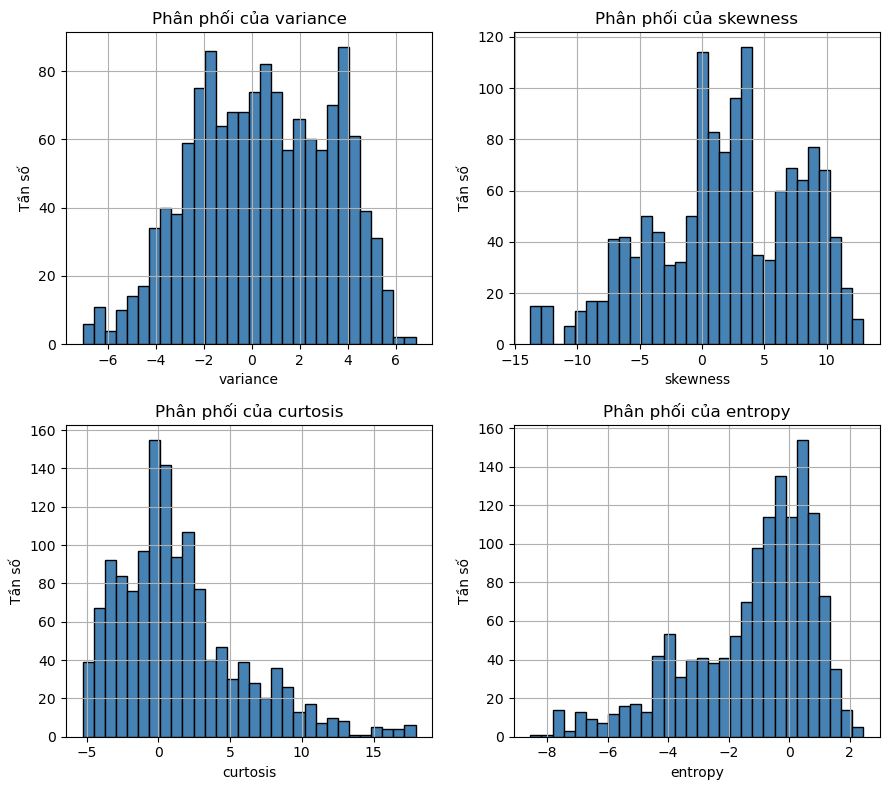

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
features = ["variance", "skewness", "curtosis", "entropy"]

for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    df_dataset[col].hist(ax=ax, bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'Phân phối của {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần số')

plt.tight_layout()
plt.show()

###  Boxplot — Phát hiện outliers

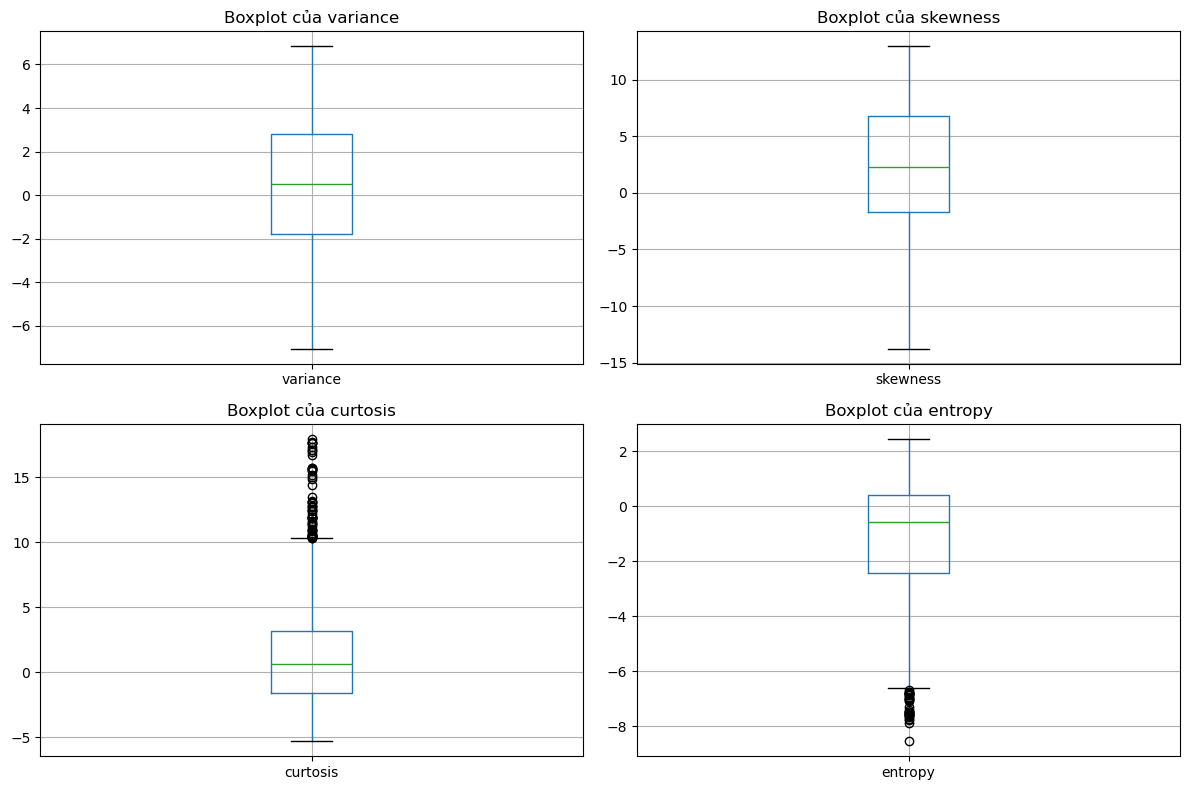

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(features):
    ax = axes[i//2, i%2]
    df_dataset.boxplot(column=col, ax=ax)
    ax.set_title(f'Boxplot của {col}')

plt.tight_layout()
plt.show()

### Correlation Heatmap — Tương quan giữa các features

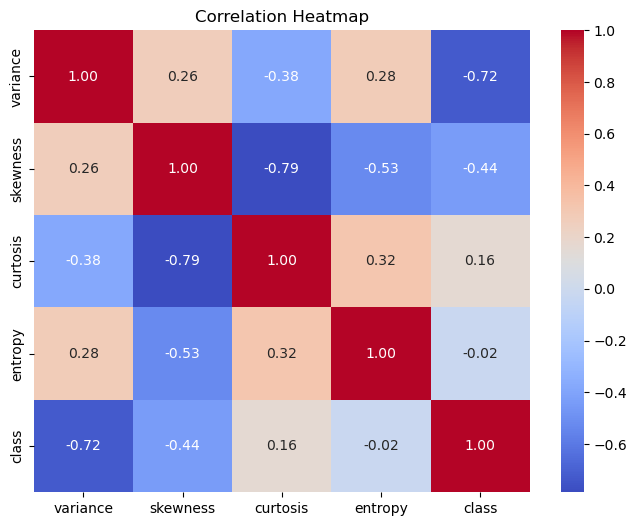

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_dataset.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Pairplot — Quan hệ giữa features theo class

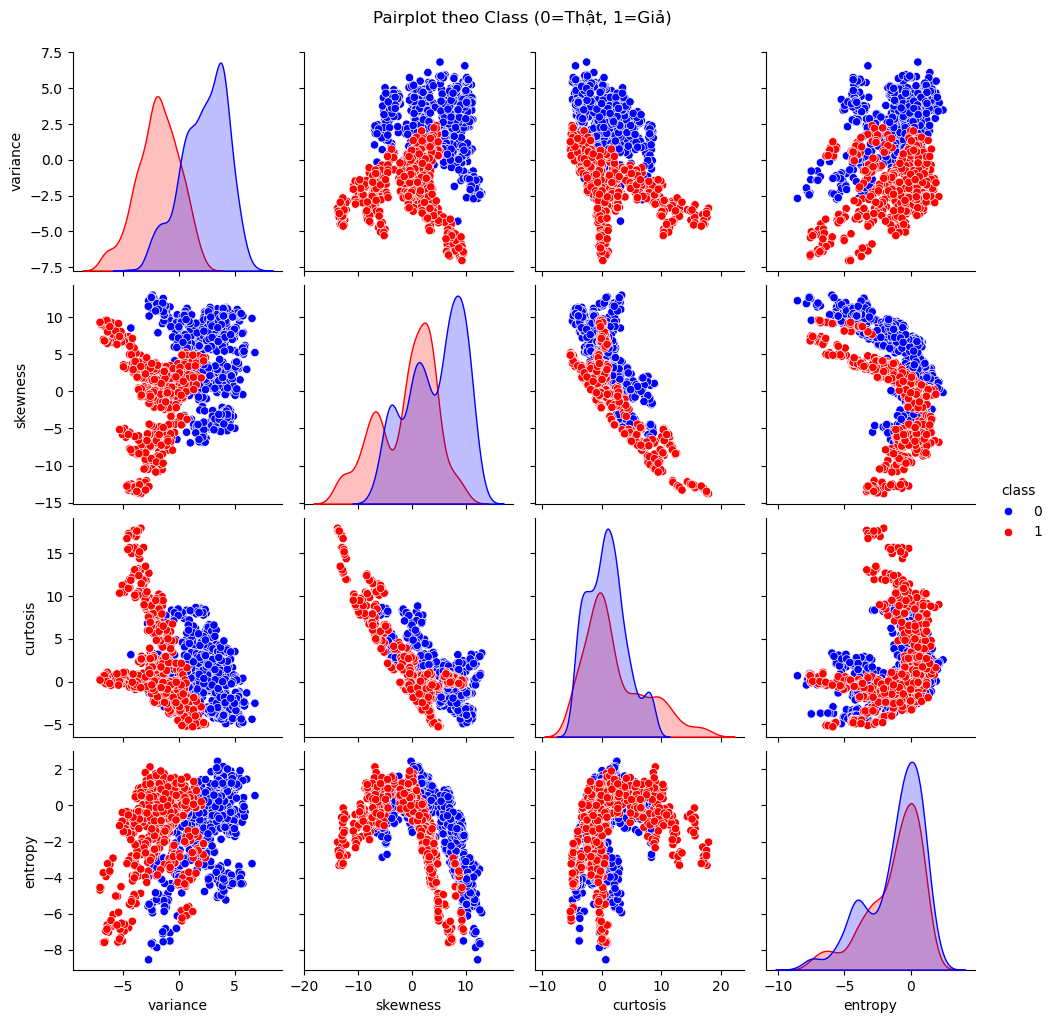

In [21]:
sns.pairplot(df_dataset, hue='class', palette={0: 'blue', 1: 'red'})
plt.suptitle('Pairplot theo Class (0=Thật, 1=Giả)', y=1.02)
plt.show()

#### (3) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [22]:
has_null = df_dataset.isnull().sum().any() # tim null, roi xem co bao nhieu gia tri null,check co cai nao lon hon 0 ko
has_nan  = df_dataset.isna().sum().any()
n_duplicated = df_dataset.duplicated().sum()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])
print(f'+ Số dòng trùng: {n_duplicated}')


Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị Nan: False
+ Số dòng trùng: 24


In [23]:
# Xóa dòng trùng lặp
df_dataset = df_dataset.drop_duplicates()
print(f"Số dòng sau khi xóa trùng: {df_dataset.shape[0]}")  
# Kết quả: 1372 - 24 = 1348 dòng

Số dòng sau khi xóa trùng: 1348


In [24]:
!jupyter nbconvert --to html EDABanknote_Authentication.ipynb

[NbConvertApp] Converting notebook EDABanknote_Authentication.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 994939 bytes to EDABanknote_Authentication.html
